# Create Regular Mesh

Notebook minimal pour fabriquer un maillage regulier `.slf` a partir d'un maillage fin TELEMAC.


In [1]:
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import matplotlib.tri as mtri
import numpy as np
from scipy.interpolate import LinearNDInterpolator
from scipy.spatial import cKDTree


def find_project_root(start: Path) -> Path:
    for path in [start.resolve(), *start.resolve().parents]:
        if (path / "python" / "create_dgl_dataset.py").exists():
            return path
    raise RuntimeError("Cannot find gnn_modulus_test project root.")


PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from python.python_code.data_manip.extraction.telemac_file import TelemacFile
from python.python_code.data_manip.formats.serafin_file import SerafinFile

os.chdir(PROJECT_ROOT)
PROJECT_ROOT


PosixPath('/users/m24046/m24046mrcr/gnn_modulus_test')

In [2]:
FINE_MESH_SLF = (
    "/work/m24046/m24046mrcr/Test_Aube_T1_regular/"
    "original_dataset/T1_V9_Topo3_KV5.slf"
)
OUTPUT_MESH_SLF = (
    "/work/m24046/m24046mrcr/Test_Aube_T1_regular/"
    "dataset_40m/Aube_regular_T1_40m.slf"
)

STEP_M = 60.0
OVERWRITE = True

In [3]:
def require_path(path_like: str) -> Path:
    path = Path(path_like).expanduser()
    if not path.exists():
        raise FileNotFoundError(path)
    return path



def build_regular_mesh(tri: mtri.Triangulation, step_m: float):
    
    #Borne du rectangle de la zone convexe 
    x_min, x_max = float(np.min(tri.x)), float(np.max(tri.x))
    y_min, y_max = float(np.min(tri.y)), float(np.max(tri.y))
    #creation de la mesh grid sur ce rectangle
    x_grid = np.arange(x_min, x_max + 0.5 * step_m, step_m, dtype=np.float64)
    y_grid = np.arange(y_min, y_max + 0.5 * step_m, step_m, dtype=np.float64)
    grid_x, grid_y = np.meshgrid(x_grid, y_grid)
    #Ravel des points
    full_xy = np.column_stack([grid_x.ravel(), grid_y.ravel()])

    #tri.get_trifinder()( fct qui renvoie le num du triangle d'appartenance du pts 
    #si il y a un triangle d'appartenance , -1 sinon 
    inside = tri.get_trifinder()(full_xy[:, 0], full_xy[:, 1]) != -1 # 1 à tt les pts inside 0 sinon 

    #pour chaque pts de la grille pas sur la bordure on prends les points en haut à droite et en diag en haut à droite
    #on créé les triangles 
    nx = len(x_grid)
    ny = len(y_grid)
    full_triangles = []
    for j in range(ny - 1):
        for i in range(nx - 1):
            n00 = j * nx + i
            n10 = n00 + 1
            n01 = n00 + nx
            n11 = n01 + 1
            full_triangles.append([n00, n10, n11])
            full_triangles.append([n00, n11, n01])

    full_triangles = np.asarray(full_triangles, dtype=np.int32)
    #donne true sur tt les triangles qui ont tous les pts inside, false sinon 
    keep = inside[full_triangles].all(axis=1)
    #on ne garde que les triangles inside
    triangles = full_triangles[keep]
    #on créé un tableau used mettant à True tt les pts utilisés dans des triangles valides 
    used = np.zeros(len(full_xy), dtype=bool)
    used[triangles.ravel()] = True
    #on créé un tableau qui donne les nouveaux indices, -1 si non utilisés de l'ancien tableau
    # de 0 à int(used.sum()) pour ceux utilisés 
    old_to_new = np.full(len(full_xy), -1, dtype=np.int32)
    old_to_new[used] = np.arange(int(used.sum()), dtype=np.int32)
    #on passe des anciens aux nouveaux indices sur les triangles
    xy = full_xy[used]
    triangles = old_to_new[triangles]
    return xy, triangles


def project(values: np.ndarray, src_xy: np.ndarray, dst_xy: np.ndarray):
    interpolator = LinearNDInterpolator(src_xy, np.asarray(values, dtype=np.float64))
    out = interpolator(dst_xy)
    missing = np.isnan(out)
    if np.any(missing):
        tree = cKDTree(src_xy)
        _, idx = tree.query(dst_xy[missing])
        out[missing] = values[idx]
    return np.asarray(out, dtype=np.float64)


def write_regular_slf(path_like: str, xy: np.ndarray, triangles: np.ndarray, bottom: np.ndarray, friction: np.ndarray, overwrite: bool):
    path = Path(path_like).expanduser()
    path.parent.mkdir(parents=True, exist_ok=True)
    if path.exists():
        if not overwrite:
            raise FileExistsError(path)
        path.unlink()

    out = SerafinFile(str(path), "SERAFIN", access="w")
    out.set_header("REGULAR MESH", 2, ["FOND", "FROTTEMENT"], ["M", ""])
    out.set_mesh(
        mesh_dim=2,
        typ_elem=None,
        ndp=3,
        nptfr=0,
        nptir=0,
        nelem=len(triangles),
        npoin=len(xy),
        ikles=np.asarray(triangles, dtype=np.int32),
        ipobo=np.zeros(len(xy), dtype=np.int32),
        knolg=np.zeros(len(xy), dtype=np.int32),
        coordx=np.asarray(xy[:, 0], dtype=np.float64),
        coordy=np.asarray(xy[:, 1], dtype=np.float64),
        nplan=1,
        date=[2026, 1, 1],
        time=[0, 0, 0],
        x_orig=0,
        y_orig=0,
    )
    out.add_data("FOND", "M", time=0.0, record=0, first_var=True, values=np.asarray(bottom, dtype=np.float64))
    out.add_data("FROTTEMENT", "", time=0.0, record=0, first_var=False, values=np.asarray(friction, dtype=np.float64))
    out.close()
    return path


In [4]:
import dgl
fine_mesh = TelemacFile(FINE_MESH_SLF)

In [5]:
fine_xy = np.column_stack([fine_mesh.meshx[:fine_mesh.npoin2], fine_mesh.meshy[:fine_mesh.npoin2]]).astype(np.float64)
bottom = fine_mesh.get_data_value("FOND",0)
friction = fine_mesh.get_data_value("FROTTEMENT",0)

regular_xy, regular_triangles = build_regular_mesh(fine_mesh.tri, STEP_M)
regular_bottom = project(bottom, fine_xy, regular_xy)
regular_friction = project(friction, fine_xy, regular_xy)

print("fine nodes:", len(fine_xy))
print("regular nodes:", len(regular_xy))
print("regular triangles:", len(regular_triangles))
print("bottom range:", float(np.min(regular_bottom)), float(np.max(regular_bottom)))
print("friction range:", float(np.min(regular_friction)), float(np.max(regular_friction)))


fine nodes: 373444
regular nodes: 33863
regular triangles: 64421
bottom range: 150.05247697967715 264.62831967530803
friction range: 2.9999999999999996 70.0


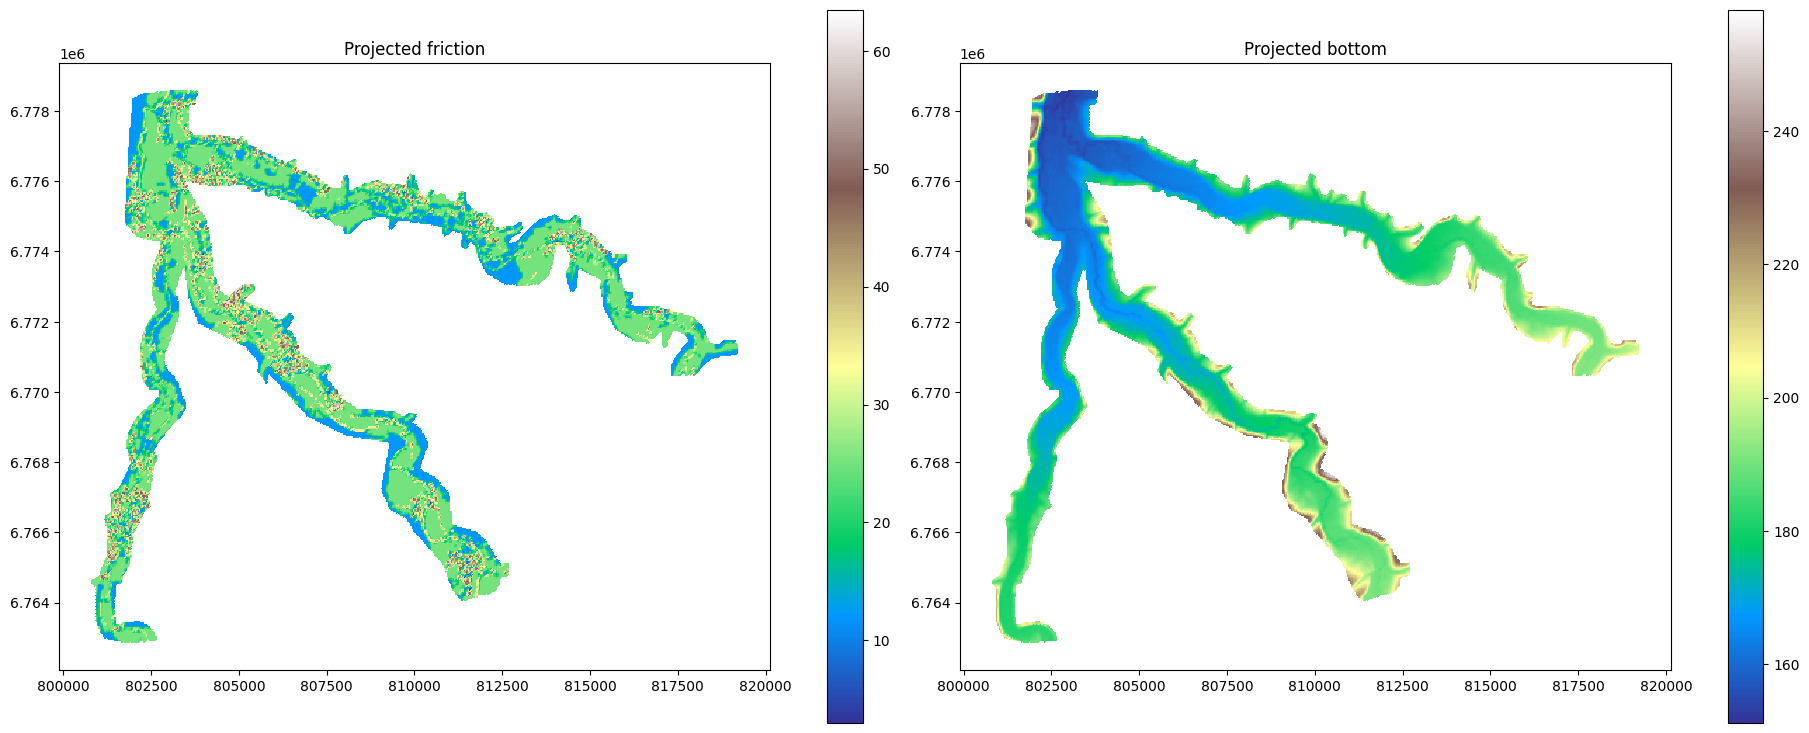

written: /work/m24046/m24046mrcr/Test_Aube_T1_regular/dataset_40m/Aube_regular_T1_40m.slf


In [6]:
idx = np.arange(len(fine_xy)) if len(fine_xy) <= 200_000 else np.random.default_rng(0).choice(len(fine_xy), 200_000, replace=False)
regular_tri = mtri.Triangulation(regular_xy[:, 0], regular_xy[:, 1], regular_triangles)

fig, axes = plt.subplots(1, 2, figsize=(18, 9), constrained_layout=True)

artist = axes[0].tripcolor(regular_tri, regular_friction, shading="flat", cmap="terrain")
axes[0].set_title("Projected friction")
axes[0].set_aspect("equal")
fig.colorbar(artist, ax=axes[0], shrink=0.8)

artist = axes[1].tripcolor(regular_tri, regular_bottom, shading="flat", cmap="terrain")
axes[1].set_title("Projected bottom")
axes[1].set_aspect("equal")
fig.colorbar(artist, ax=axes[1], shrink=0.8)

plt.show()

output_path = write_regular_slf(
    OUTPUT_MESH_SLF,
    regular_xy,
    regular_triangles,
    regular_bottom,
    regular_friction,
    OVERWRITE,
)

print("written:", output_path)


In [7]:
regular_mesh = TelemacFile(OUTPUT_MESH_SLF)

In [8]:
x = np.asarray(regular_mesh.meshx[:regular_mesh.npoin2], dtype=np.float64)
y = np.asarray(regular_mesh.meshy[:regular_mesh.npoin2], dtype=np.float64)
triangles = np.asarray(regular_mesh.ikle2, dtype=np.int64)

bottom = regular_mesh.get_data_value("FOND",0)
friction = regular_mesh.get_data_value("FROTTEMENT",0)

tri = mtri.Triangulation(x, y, triangles)

print("nodes:", len(x))
print("triangles:", len(triangles))
print("variables:", regular_mesh.varnames)
print("bottom range:", float(np.min(bottom)), float(np.max(bottom)))
print("friction range:", float(np.min(friction)), float(np.max(friction)))

nodes: 33863
triangles: 64421
variables: ['FOND', 'FROTTEMENT']
bottom range: 150.05247497558594 264.6283264160156
friction range: 3.0 70.0


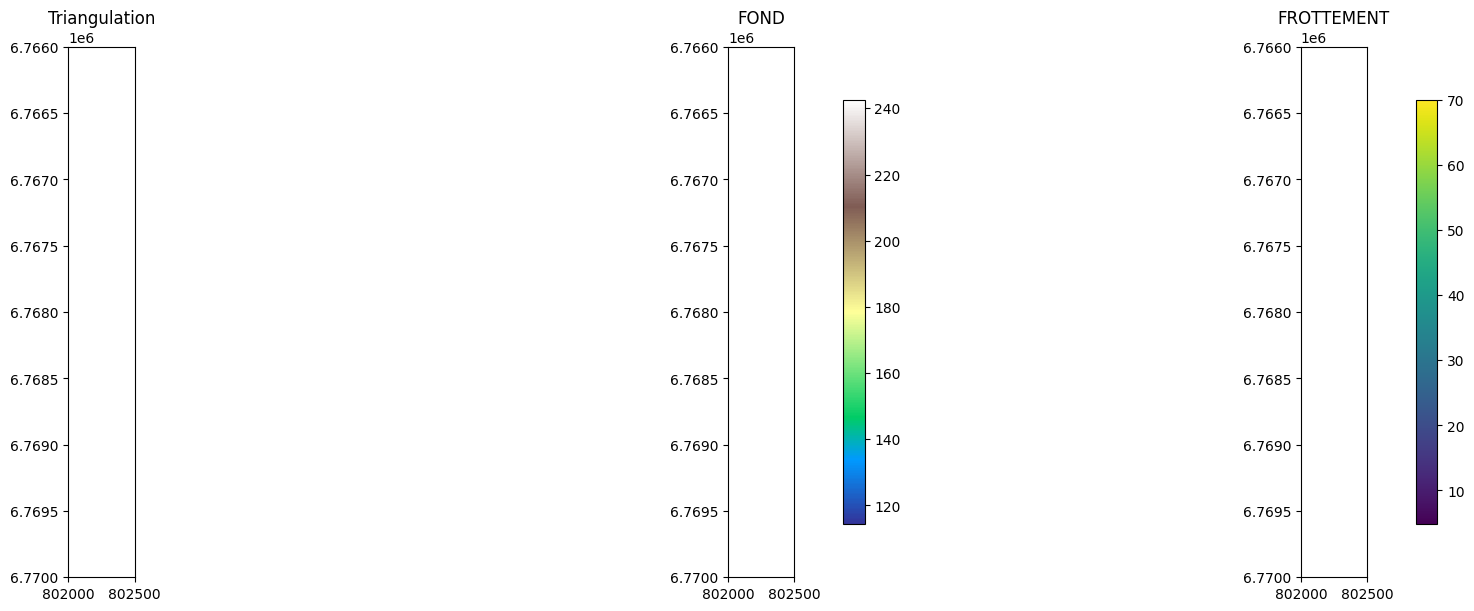

In [9]:
ZOOM_XLIM = (802000.0, 802500.0)
ZOOM_YLIM = (6770000, 6766000)

fig, axes = plt.subplots(1, 3, figsize=(16, 6), constrained_layout=True)

axes[0].triplot(regular_tri, color="black", linewidth=0.4)
axes[0].set_xlim(*ZOOM_XLIM)
axes[0].set_ylim(*ZOOM_YLIM)
axes[0].set_title("Triangulation")
axes[0].set_aspect("equal")

im_bottom = axes[1].tripcolor(
    regular_tri,
    regular_bottom,
    shading="flat",
    cmap="terrain",
)
axes[1].triplot(regular_tri, color="black", linewidth=0.15, alpha=0.5)
axes[1].set_xlim(*ZOOM_XLIM)
axes[1].set_ylim(*ZOOM_YLIM)
axes[1].set_title("FOND")
axes[1].set_aspect("equal")
fig.colorbar(im_bottom, ax=axes[1], shrink=0.8)

im_friction = axes[2].tripcolor(
    regular_tri,
    regular_friction,
    shading="flat",
    cmap="viridis",
)
axes[2].triplot(regular_tri, color="black", linewidth=0.15, alpha=0.5)
axes[2].set_xlim(*ZOOM_XLIM)
axes[2].set_ylim(*ZOOM_YLIM)
axes[2].set_title("FROTTEMENT")
axes[2].set_aspect("equal")
fig.colorbar(im_friction, ax=axes[2], shrink=0.8)

plt.show()